In [1]:
import os
import sys
import time
import json
import threading
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import map_coordinates, gaussian_filter
import pynq
from pynq import allocate
from pynq_dpu import DpuOverlay
import xir
import vart


In [2]:
from pathlib import Path
import hashlib

DPU_BITSTREAM = "dpu.bit"
PIPELINE_VERSION = "v4-canonical-letterbox"
WINDOW_RADIUS = 3
N_STACK = 8
INPUT_HEIGHT, INPUT_WIDTH = 112, 96
INPUT_CHANNELS = 16
CANONICAL_VOLUME_SHAPE = (96, 112, 96)  # [D, H, W]
PAD_VALUE = -1.0
SEG_LABELS = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]
OUTPUT_DIR = "./fpga_results_v4_canonical"

QUIVER_AUTO_GAIN = True
QUIVER_TARGET_P95 = 2.0
QUIVER_MAX_GAIN = 20.0
QUIVER_DISPLAY_FLIP_Y = True


def resolve_file(default_path, extra_candidates=None):
    candidates = [Path(default_path)]
    for candidate in extra_candidates or []:
        candidates.append(Path(candidate))
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return str(candidates[0])


XMODEL_PATH = resolve_file(
    './vxm_2p5d_pt_v4_canonical.xmodel',
    [
        '../../out/v4_canonical/vxm_2p5d_pt_v4_canonical/compiled/vxm_2p5d_pt_v4_canonical.xmodel',
        './out/v4_canonical/vxm_2p5d_pt_v4_canonical/compiled/vxm_2p5d_pt_v4_canonical.xmodel',
    ],
)
MR_VOLUME_PATH = resolve_file('./1BA001_mr.npy', ['./data/test_data/1BA001_mr.npy'])
CT_VOLUME_PATH = resolve_file('./1BA005_ct.npy', ['./data/test_data/1BA005_ct.npy'])
MR_SEG_PATH = resolve_file('./1BA001_mr_seg.npy', ['./data/test_data/1BA001_mr_seg.npy'])
CT_SEG_PATH = resolve_file('./1BA005_ct_seg.npy', ['./data/test_data/1BA005_ct_seg.npy'])
CPU_EXPORT_HELPER = resolve_file('./vxm_2p5d_export.py', ['/home/felipepuentec/FPGA_Inference/vxm_2p5d_export.py'])
if not Path(CPU_EXPORT_HELPER).exists():
    raise FileNotFoundError(f'Missing CPU reference helper: {CPU_EXPORT_HELPER}. Upload vxm_2p5d_export.py with this notebook.')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Configuration:')
print(f'  Pipeline: {PIPELINE_VERSION}')
print(f'  XMODEL: {XMODEL_PATH}')
print('  Test data: CROSS-SUBJECT (1BA001 MR -> 1BA005 CT)')
print(f'  FPGA input: [1, {INPUT_HEIGHT}, {INPUT_WIDTH}, {INPUT_CHANNELS}]')
print(f'  Canonical volume: {CANONICAL_VOLUME_SHAPE}')
print(f'  Stack size: {N_STACK} slices (seven-slice window + duplicated edge)')
print('  Preprocessing: trilinear canonical image resample, nearest-label resample, orientation-aware letterbox')
print(f'  Output dir: {OUTPUT_DIR}')


Configuration:
  Pipeline: v4-canonical-letterbox
  XMODEL: vxm_2p5d_pt_v4_canonical.xmodel
  Test data: CROSS-SUBJECT (1BA001 MR -> 1BA005 CT)
  FPGA input: [1, 112, 96, 16]
  Canonical volume: (96, 112, 96)
  Stack size: 8 slices (seven-slice window + duplicated edge)
  Preprocessing: trilinear canonical image resample, nearest-label resample, orientation-aware letterbox
  Output dir: ./fpga_results_v4_canonical


In [3]:
overlay = DpuOverlay(DPU_BITSTREAM)
graph = xir.Graph.deserialize(XMODEL_PATH)
subgraphs = graph.get_root_subgraph().toposort_child_subgraph()

dpu_subgraph = None
for subgraph in subgraphs:
    if subgraph.get_attr('device') == "DPU":
        dpu_subgraph = subgraph
        break

if dpu_subgraph is None:
    raise RuntimeError("No DPU subgraph found")

dpu_runner = vart.Runner.create_runner(dpu_subgraph, "run")

/usr/local/share/pynq-venv/lib/python3.10/site-packages/pynq/ps.py:434: UserWarning: Setting frequency to the closest possible value 98.8879MHz.
  warnings.warn(


In [4]:
input_tensors = dpu_runner.get_input_tensors()
output_tensors = dpu_runner.get_output_tensors()

print('=' * 70)
print('V4 QUANTIZATION AND CONTRACT CHECK')
print('=' * 70)

if len(input_tensors) != 1:
    raise RuntimeError(f'V4 requires one fused NHWC input tensor, found {len(input_tensors)}')
if len(output_tensors) != 1:
    raise RuntimeError(f'V4 requires one flow output tensor, found {len(output_tensors)}')

input_shape = tuple(input_tensors[0].dims)
output_shape = tuple(output_tensors[0].dims)
expected_input_shape = (1, INPUT_HEIGHT, INPUT_WIDTH, INPUT_CHANNELS)
if input_shape != expected_input_shape:
    raise RuntimeError(f'Wrong V4 xmodel input shape: expected {expected_input_shape}, got {input_shape}')
if output_shape != (1, INPUT_HEIGHT, INPUT_WIDTH, 2):
    raise RuntimeError(f'Wrong V4 xmodel output shape: expected [1,112,96,2], got {output_shape}')

INPUT_SCALE = 2 ** input_tensors[0].get_attr('fix_point')
OUTPUT_SCALE = 2 ** output_tensors[0].get_attr('fix_point')
print(f'Input:  {input_tensors[0].name}: {input_shape}, scale={INPUT_SCALE}')
print(f'Output: {output_tensors[0].name}: {output_shape}, scale={OUTPUT_SCALE}')
print('Input contract: moving[8] followed by fixed[8], NHWC, int8 quantized.')
print('Output contract: NHWC two-component 2D pull flow; float = int8 / output_scale.')


V4 QUANTIZATION AND CONTRACT CHECK
Input:  Vxm2p5dV4__input_0_fix: (1, 112, 96, 16), scale=64
Output: Vxm2p5dV4__Vxm2p5dV4_Conv2d_flow_scale__2217_fix: (1, 112, 96, 2), scale=32
Input contract: moving[8] followed by fixed[8], NHWC, int8 quantized.
Output contract: NHWC two-component 2D pull flow; float = int8 / output_scale.


In [5]:
import torch
import torch.nn.functional as F


def normalize_volume_contract(volume):
    arr = volume.astype(np.float32)
    arr_min = float(arr.min())
    arr_max = float(arr.max())
    if arr_max <= arr_min:
        return np.zeros_like(arr, dtype=np.float32)
    if arr_min >= -1.001 and arr_max <= 1.001:
        if arr_min >= -1e-4 and arr_max <= 1.0001:
            return (2.0 * arr - 1.0).astype(np.float32)
        return arr
    return (2.0 * (arr - arr_min) / (arr_max - arr_min) - 1.0).astype(np.float32)


def resample_volume_v4(volume, is_segmentation=False):
    """Resample a raw [D,H,W] volume to V4's shared canonical grid."""
    tensor = torch.from_numpy(np.ascontiguousarray(volume.astype(np.float32)))[None, None]
    if is_segmentation:
        result = F.interpolate(tensor, size=CANONICAL_VOLUME_SHAPE, mode='nearest')
        return np.ascontiguousarray(result[0, 0].numpy().astype(np.int16))
    result = F.interpolate(tensor, size=CANONICAL_VOLUME_SHAPE, mode='trilinear', align_corners=False)
    return np.ascontiguousarray(result[0, 0].numpy().astype(np.float32))


def extract_v4_stack(volume, orientation, z):
    """Extract V4's native seven-slice stack from a canonical [D,H,W] volume."""
    if orientation == 'axial':
        stack = volume[z - WINDOW_RADIUS:z + WINDOW_RADIUS + 1]
    elif orientation == 'coronal':
        stack = volume[:, z - WINDOW_RADIUS:z + WINDOW_RADIUS + 1, :].transpose(1, 0, 2)
    elif orientation == 'sagittal':
        stack = volume[:, :, z - WINDOW_RADIUS:z + WINDOW_RADIUS + 1].transpose(2, 0, 1)
    else:
        raise ValueError(f'Unknown orientation: {orientation}')
    if stack.shape[0] != N_STACK - 1:
        raise RuntimeError(f'Expected seven source slices, got {stack.shape}')
    return np.ascontiguousarray(stack)


def _canonicalize_orientation(array, orientation):
    return np.ascontiguousarray(np.swapaxes(array, -2, -1)) if orientation == 'sagittal' else np.ascontiguousarray(array)


def letterbox_stack_v4(stack, orientation):
    """Convert a native V4 stack to [8,112,96] without aspect-ratio distortion."""
    if stack.shape[0] == N_STACK - 1:
        stack = np.concatenate([stack, stack[-1:]], axis=0)
    if stack.shape[0] != N_STACK:
        raise ValueError(f'Expected {N_STACK} stack slices, got {stack.shape}')
    canonical = _canonicalize_orientation(stack, orientation)
    out = np.full((N_STACK, INPUT_HEIGHT, INPUT_WIDTH), PAD_VALUE, dtype=np.float32)
    if canonical.shape[1:] == (INPUT_HEIGHT, INPUT_WIDTH):
        out[...] = canonical
    elif orientation == 'coronal' and canonical.shape[1:] == (96, 96):
        out[:, 8:104, :] = canonical
    else:
        raise ValueError(f'Unexpected {orientation} plane shape: {canonical.shape[1:]}')
    return np.ascontiguousarray(out)


def letterbox_plane_v4(plane, orientation, is_segmentation=False):
    canonical = _canonicalize_orientation(plane, orientation)
    pad_value = 0 if is_segmentation else PAD_VALUE
    out = np.full((INPUT_HEIGHT, INPUT_WIDTH), pad_value, dtype=np.int16 if is_segmentation else np.float32)
    if canonical.shape == (INPUT_HEIGHT, INPUT_WIDTH):
        out[...] = canonical
    elif orientation == 'coronal' and canonical.shape == (96, 96):
        out[8:104, :] = canonical
    else:
        raise ValueError(f'Unexpected {orientation} plane shape: {canonical.shape}')
    return np.ascontiguousarray(out)


def canvas_flow_to_native_v4(flow, orientation):
    """Undo V4 canvas geometry; return native [N,2,H,W] flow for lifting."""
    if orientation == 'axial':
        return flow
    if orientation == 'coronal':
        return np.ascontiguousarray(flow[:, :, 8:104, :])
    native = np.empty((flow.shape[0], 2, 96, 112), dtype=np.float32)
    native[:, 0] = flow[:, 1].transpose(0, 2, 1)
    native[:, 1] = flow[:, 0].transpose(0, 2, 1)
    return native


def apply_flow_2d(image, flow, interpolation=cv2.INTER_LINEAR):
    h, w = image.shape
    y_coords, x_coords = np.mgrid[0:h, 0:w].astype(np.float32)
    return cv2.remap(image.astype(np.float32), x_coords + flow[0], y_coords + flow[1], interpolation, borderMode=cv2.BORDER_CONSTANT)


def _quiver_vis_gain(flow, target_p95=2.0, max_gain=20.0):
    magnitude = np.sqrt(flow[0] ** 2 + flow[1] ** 2)
    p95 = float(np.percentile(magnitude, 95))
    return (1.0 if p95 <= 1e-8 else float(np.clip(target_p95 / p95, 1.0, max_gain))), p95


def plot_quiver(ax, flow, background=None, step=4, auto_gain=True, target_p95=2.0, max_gain=20.0, display_flip_y=False):
    h, w = flow.shape[1:]
    gain, p95 = _quiver_vis_gain(flow, target_p95, max_gain) if auto_gain else (1.0, 0.0)
    y, x = np.mgrid[0:h:step, 0:w:step]
    fx, fy = flow[0, ::step, ::step] * gain, flow[1, ::step, ::step] * gain
    if display_flip_y:
        fy = -fy
    ax.imshow(np.asarray(background) if background is not None else np.zeros((h, w)), cmap='gray', origin='upper')
    ax.quiver(x, y, fx, fy, color='red', angles='xy', scale_units='xy', scale=1, headwidth=3, headlength=4, alpha=0.8)
    ax.set_xlim(0, w - 1); ax.set_ylim(h - 1, 0)
    return gain, p95


def _run_int8_dpu(input_data):
    input_buf = output_buf = None
    try:
        input_buf = allocate(shape=tuple(input_data.shape), dtype=np.int8)
        np.copyto(input_buf, np.ascontiguousarray(input_data, dtype=np.int8))
        if hasattr(input_buf, 'sync_to_device'): input_buf.sync_to_device()
        output_buf = allocate(shape=tuple(output_shape), dtype=np.int8)
        job_id = dpu_runner.execute_async([input_buf], [output_buf])
        dpu_runner.wait(job_id)
        if hasattr(output_buf, 'sync_from_device'): output_buf.sync_from_device()
        return np.array(output_buf, copy=True)
    finally:
        if input_buf is not None and hasattr(input_buf, 'freebuffer'): input_buf.freebuffer()
        if output_buf is not None and hasattr(output_buf, 'freebuffer'): output_buf.freebuffer()


def run_dpu_inference(moving_stack, fixed_stack):
    if moving_stack.shape != (N_STACK, INPUT_HEIGHT, INPUT_WIDTH) or fixed_stack.shape != moving_stack.shape:
        raise ValueError(f'Expected paired V4 stacks [8,112,96], got {moving_stack.shape} and {fixed_stack.shape}')
    combined = np.concatenate([moving_stack, fixed_stack], axis=0)
    input_data = combined.transpose(1, 2, 0)[None].astype(np.float32)
    if tuple(input_data.shape) != input_shape:
        raise RuntimeError(f'Prepared input {input_data.shape} does not match xmodel {input_shape}')
    quantized = np.clip(np.round(input_data * INPUT_SCALE), -128, 127).astype(np.int8)
    start = time.perf_counter()
    output_data = _run_int8_dpu(quantized)
    duration = time.perf_counter() - start
    flow = output_data.astype(np.float32) / OUTPUT_SCALE
    return np.ascontiguousarray(flow[0].transpose(2, 0, 1)), duration


In [6]:
SEG_LABELS = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]


def compute_dice_per_label(seg_a, seg_b, labels=SEG_LABELS):
    scores = []
    for label in labels:
        a, b = (seg_a == label), (seg_b == label)
        union = float(a.sum() + b.sum())
        scores.append(1.0 if union == 0.0 else float(2.0 * (a * b).sum() / union))
    return np.asarray(scores, dtype=np.float32)


def mutual_information_np(a, b, bins=64, clip_range=(-1.0, 1.0)):
    hist, _, _ = np.histogram2d(a.ravel(), b.ravel(), bins=bins, range=[clip_range, clip_range])
    pxy = hist / max(hist.sum(), 1.0); px, py = pxy.sum(axis=1, keepdims=True), pxy.sum(axis=0, keepdims=True)
    nz = pxy > 0
    return float((pxy[nz] * np.log(pxy[nz] / (px @ py)[nz])).sum())


def structural_similarity_np(a, b, data_range=2.0, sigma=1.5, truncate=3.5, eps=1e-8):
    mu_a, mu_b = gaussian_filter(a, sigma=sigma, mode='reflect', truncate=truncate), gaussian_filter(b, sigma=sigma, mode='reflect', truncate=truncate)
    c1, c2 = (0.01 * data_range) ** 2, (0.03 * data_range) ** 2
    var_a = np.maximum(gaussian_filter(a * a, sigma=sigma, mode='reflect', truncate=truncate) - mu_a * mu_a, 0.0)
    var_b = np.maximum(gaussian_filter(b * b, sigma=sigma, mode='reflect', truncate=truncate) - mu_b * mu_b, 0.0)
    cov = gaussian_filter(a * b, sigma=sigma, mode='reflect', truncate=truncate) - mu_a * mu_b
    return float(((2.0 * mu_a * mu_b + c1) * (2.0 * cov + c2) / np.maximum((mu_a * mu_a + mu_b * mu_b + c1) * (var_a + var_b + c2), eps)).mean())


def warp_volume_3d_numpy(volume, flow_xyz, mode='linear'):
    d, h, w = volume.shape
    zz, yy, xx = np.meshgrid(np.arange(d), np.arange(h), np.arange(w), indexing='ij')
    coords = np.stack([zz + flow_xyz[2], yy + flow_xyz[1], xx + flow_xyz[0]], axis=0)
    return map_coordinates(volume.astype(np.float32), coords, order=1 if mode == 'linear' else 0, mode='nearest')


def resize_component_3d(component, target_shape):
    tensor = torch.from_numpy(component[None, None].astype(np.float32))
    return F.interpolate(tensor, size=target_shape, mode='trilinear', align_corners=False)[0, 0].numpy().astype(np.float32)


def canonical_field_to_raw(field_xyz, raw_shape):
    scale = (raw_shape[2] / 96.0, raw_shape[1] / 112.0, raw_shape[0] / 96.0)
    return np.stack([resize_component_3d(field_xyz[channel], raw_shape) * factor for channel, factor in enumerate(scale)]).astype(np.float32)


def lift_axial_v4(flow_stack, canonical_shape=CANONICAL_VOLUME_SHAPE):
    out = np.zeros((3, *canonical_shape), dtype=np.float32)
    for index, z in enumerate(range(WINDOW_RADIUS, canonical_shape[0] - WINDOW_RADIUS)):
        out[0, z], out[1, z] = flow_stack[index, 0], flow_stack[index, 1]
    return out


def lift_coronal_v4(flow_stack, canonical_shape=CANONICAL_VOLUME_SHAPE):
    out = np.zeros((3, *canonical_shape), dtype=np.float32)
    for index, y in enumerate(range(WINDOW_RADIUS, canonical_shape[1] - WINDOW_RADIUS)):
        out[0, :, y, :], out[2, :, y, :] = flow_stack[index, 0], flow_stack[index, 1]
    return out


def lift_sagittal_v4(flow_stack, canonical_shape=CANONICAL_VOLUME_SHAPE):
    out = np.zeros((3, *canonical_shape), dtype=np.float32)
    for index, x in enumerate(range(WINDOW_RADIUS, canonical_shape[2] - WINDOW_RADIUS)):
        out[1, :, :, x], out[2, :, :, x] = flow_stack[index, 0], flow_stack[index, 1]
    return out


def fuse_fields(axial, coronal, sagittal):
    fused = np.zeros_like(axial)
    fused[0], fused[1], fused[2] = 0.5 * (axial[0] + coronal[0]), 0.5 * (axial[1] + sagittal[1]), 0.5 * (coronal[2] + sagittal[2])
    return fused


def smooth_field_3d(field, sigma=0.75):
    return np.stack([gaussian_filter(component, sigma=sigma).astype(np.float32) for component in field])


def _label_centroid_dhw(segmentation, label):
    coordinates = np.argwhere(segmentation == label)
    return None if coordinates.size == 0 else coordinates.mean(axis=0).astype(np.float32)


def label_centroid_tre_metrics(moving_seg, warped_seg, fixed_seg, spacing_dhw_mm=(1.0, 1.0, 1.0)):
    spacing = np.asarray(spacing_dhw_mm, dtype=np.float32)
    before, after, per_label, missing = [], [], {}, []
    for label in SEG_LABELS:
        moving_center, fixed_center = _label_centroid_dhw(moving_seg, label), _label_centroid_dhw(fixed_seg, label)
        if moving_center is None or fixed_center is None: continue
        before.append(float(np.linalg.norm((moving_center - fixed_center) * spacing)))
        warped_center = _label_centroid_dhw(warped_seg, label)
        if warped_center is None:
            missing.append(int(label)); continue
        error = float(np.linalg.norm((warped_center - fixed_center) * spacing))
        after.append(error); per_label[str(int(label))] = error
    return {'tre_before_mm': float(np.mean(before)) if before else None, 'tre_mm': float(np.mean(after)) if after else None, 'tre_median_mm': float(np.median(after)) if after else None, 'tre_label_count': len(after), 'tre_missing_warped_labels': missing, 'tre_per_label_mm': per_label}


def summarize_registration(moving_vol, fixed_vol, moving_seg, fixed_seg, flow, warped_vol, warped_seg):
    dice_before, dice_after = compute_dice_per_label(moving_seg, fixed_seg), compute_dice_per_label(warped_seg, fixed_seg)
    metrics = {'mi_before': mutual_information_np(moving_vol, fixed_vol), 'mi_after': mutual_information_np(warped_vol, fixed_vol), 'ssim_deformed_fixed': structural_similarity_np(warped_vol, fixed_vol), 'ssim_deformed_moving': structural_similarity_np(warped_vol, moving_vol), 'dice_before': float(dice_before.mean()), 'dice_after': float(dice_after.mean()), 'flow_min': float(flow.min()), 'flow_max': float(flow.max()), 'flow_mean': float(flow.mean()), 'flow_std': float(flow.std())}
    metrics.update(label_centroid_tre_metrics(moving_seg, warped_seg, fixed_seg))
    return metrics


MODEL_CPU = None

def run_cpu_inference(moving_stack, fixed_stack, weights_path):
    global MODEL_CPU
    if MODEL_CPU is None:
        import sys
        helper_dir = str(Path(CPU_EXPORT_HELPER).resolve().parent)
        if helper_dir not in sys.path: sys.path.insert(0, helper_dir)
        from vxm_2p5d_export import load_model_for_export
        print(f'Loading V4 PyTorch CPU model from {weights_path}...')
        MODEL_CPU = load_model_for_export(weights_path).to('cpu').eval()
    input_data = np.concatenate([moving_stack, fixed_stack], axis=0).transpose(1, 2, 0)[None].astype(np.float32)
    start = time.perf_counter()
    with torch.no_grad(): flow = MODEL_CPU(torch.from_numpy(input_data)).squeeze(0).numpy()
    return flow.astype(np.float32), time.perf_counter() - start


def infer_v4_orientation(moving_c, fixed_c, orientation, device, weights_path=None):
    axis = {'axial': 0, 'coronal': 1, 'sagittal': 2}[orientation]
    flows, times = [], []
    for z in range(WINDOW_RADIUS, moving_c.shape[axis] - WINDOW_RADIUS):
        moving_stack = letterbox_stack_v4(extract_v4_stack(moving_c, orientation, z), orientation)
        fixed_stack = letterbox_stack_v4(extract_v4_stack(fixed_c, orientation, z), orientation)
        flow, elapsed = run_dpu_inference(moving_stack, fixed_stack) if device == 'fpga' else run_cpu_inference(moving_stack, fixed_stack, weights_path)
        flows.append(flow); times.append(elapsed)
    return canvas_flow_to_native_v4(np.stack(flows).astype(np.float32), orientation), times


class PowerMonitor:
    def __init__(self, device_name, sample_interval_s=0.10, idle_dpu_w=0.0, idle_cpu_w=0.0):
        self.device_name = device_name
        self.sample_interval_s = sample_interval_s
        self.idle_dpu_w = float(idle_dpu_w)
        self.idle_cpu_w = float(idle_cpu_w)
        self.gpu_samples_w = []
        self.cpu_samples_w = []
        self.memory_samples_mb = []
        self._stop = False
        self._thread = None
        self._start_rss_mb = None
        self._end_rss_mb = None
        self._start_wall = None
        self._end_wall = None
        self.rails = pynq.get_rails()

    @staticmethod
    def _read_rss_mb():
        try:
            with open('/proc/self/status', 'r') as f:
                for line in f:
                    if line.startswith('VmRSS:'):
                        return float(line.split()[1]) / 1024.0
        except Exception:
            pass
        return 0.0

    def _sample_power_and_memory(self):
        while not self._stop:
            if 'INT' in self.rails and self.rails['INT'].power:
                self.gpu_samples_w.append(self.rails['INT'].power.value)
            if 'PSINTFP' in self.rails and self.rails['PSINTFP'].power:
                self.cpu_samples_w.append(self.rails['PSINTFP'].power.value)
            self.memory_samples_mb.append(self._read_rss_mb())
            time.sleep(self.sample_interval_s)

    def __enter__(self):
        self._start_rss_mb = self._read_rss_mb()
        self.memory_samples_mb.append(self._start_rss_mb)
        self._start_wall = time.perf_counter()
        self._stop = False
        self._thread = threading.Thread(target=self._sample_power_and_memory, daemon=True)
        self._thread.start()
        return self

    def __exit__(self, exc_type, exc, tb):
        self._end_wall = time.perf_counter()
        self._end_rss_mb = self._read_rss_mb()
        self.memory_samples_mb.append(self._end_rss_mb)
        self._stop = True
        if self._thread is not None:
            self._thread.join(timeout=1.0)
        return False

    def result(self):
        wall_time_s = 0.0
        if self._start_wall is not None and self._end_wall is not None:
            wall_time_s = max(float(self._end_wall - self._start_wall), 0.0)

        gpu_power_mean_w = None
        gpu_power_peak_w = None
        gpu_energy_j = None
        gpu_dynamic_energy_j = None
        if self.gpu_samples_w:
            gpu_power_mean_w = float(np.mean(self.gpu_samples_w))
            gpu_power_peak_w = float(np.max(self.gpu_samples_w))
            gpu_energy_j = float(gpu_power_mean_w * wall_time_s)
            gpu_dynamic_energy_j = float(max(gpu_energy_j - (self.idle_dpu_w * wall_time_s), 0.0))

        cpu_power_mean_w = None
        cpu_energy_j = None
        cpu_dynamic_energy_j = None
        if self.cpu_samples_w:
            cpu_power_mean_w = float(np.mean(self.cpu_samples_w))
            cpu_energy_j = float(cpu_power_mean_w * wall_time_s)
            cpu_dynamic_energy_j = float(max(cpu_energy_j - (self.idle_cpu_w * wall_time_s), 0.0))

        energy_parts = [v for v in [cpu_energy_j, gpu_energy_j] if v is not None]
        energy_j = float(sum(energy_parts)) if energy_parts else None
        
        dynamic_energy_parts = [v for v in [cpu_dynamic_energy_j, gpu_dynamic_energy_j] if v is not None]
        dynamic_energy_j = float(sum(dynamic_energy_parts)) if dynamic_energy_parts else None

        power_mean_w = None
        if energy_j is not None and wall_time_s > 0:
            power_mean_w = float(energy_j / wall_time_s)

        process_rss_peak_mb = None
        process_rss_delta_mb = None
        if self.memory_samples_mb:
            process_rss_peak_mb = float(np.max(self.memory_samples_mb))
        if self._start_rss_mb is not None and self._end_rss_mb is not None:
            process_rss_delta_mb = float(self._end_rss_mb - self._start_rss_mb)

        return {
            'power_wall_time_s': wall_time_s,
            'cpu_energy_j': cpu_energy_j,
            'cpu_dynamic_energy_j': cpu_dynamic_energy_j,
            'cpu_power_mean_w': cpu_power_mean_w,
            'gpu_energy_j': gpu_energy_j,
            'gpu_dynamic_energy_j': gpu_dynamic_energy_j,
            'gpu_power_mean_w': gpu_power_mean_w,
            'gpu_power_peak_w': gpu_power_peak_w,
            'gpu_power_samples': int(len(self.gpu_samples_w)),
            'energy_j': energy_j,
            'dynamic_energy_j': dynamic_energy_j,
            'power_mean_w': power_mean_w,
            'process_rss_start_mb': self._start_rss_mb,
            'process_rss_end_mb': self._end_rss_mb,
            'process_rss_peak_mb': process_rss_peak_mb,
            'process_rss_delta_mb': process_rss_delta_mb,
            'process_memory_samples': int(len(self.memory_samples_mb)),
        }

def combine_power_measurements(parts):
    parts = [p for p in parts if p]
    wall_time_s = sum(float(p.get('power_wall_time_s') or 0.0) for p in parts)

    def sum_known(key):
        vals = [p.get(key) for p in parts if p.get(key) is not None]
        return None if not vals else float(sum(vals))

    cpu_energy_j = sum_known('cpu_energy_j')
    cpu_dynamic_energy_j = sum_known('cpu_dynamic_energy_j')
    gpu_energy_j = sum_known('gpu_energy_j')
    gpu_dynamic_energy_j = sum_known('gpu_dynamic_energy_j')
    energy_j = sum_known('energy_j')
    dynamic_energy_j = sum_known('dynamic_energy_j')

    gpu_peak_vals = [p.get('gpu_power_peak_w') for p in parts if p.get('gpu_power_peak_w') is not None]
    gpu_samples = int(sum(int(p.get('gpu_power_samples') or 0) for p in parts))
    rss_peak_vals = [p.get('process_rss_peak_mb') for p in parts if p.get('process_rss_peak_mb') is not None]
    rss_start_vals = [p.get('process_rss_start_mb') for p in parts if p.get('process_rss_start_mb') is not None]
    rss_end_vals = [p.get('process_rss_end_mb') for p in parts if p.get('process_rss_end_mb') is not None]
    memory_samples = int(sum(int(p.get('process_memory_samples') or 0) for p in parts))
    rss_start = None if not rss_start_vals else float(rss_start_vals[0])
    rss_end = None if not rss_end_vals else float(rss_end_vals[-1])

    return {
        'power_wall_time_s': float(wall_time_s),
        'cpu_energy_j': cpu_energy_j,
        'cpu_dynamic_energy_j': cpu_dynamic_energy_j,
        'cpu_power_mean_w': None if cpu_energy_j is None or wall_time_s <= 0 else float(cpu_energy_j / wall_time_s),
        'gpu_energy_j': gpu_energy_j,
        'gpu_dynamic_energy_j': gpu_dynamic_energy_j,
        'gpu_power_mean_w': None if gpu_energy_j is None or wall_time_s <= 0 else float(gpu_energy_j / wall_time_s),
        'gpu_power_peak_w': None if not gpu_peak_vals else float(max(gpu_peak_vals)),
        'gpu_power_samples': gpu_samples,
        'energy_j': energy_j,
        'dynamic_energy_j': dynamic_energy_j,
        'power_mean_w': None if energy_j is None or wall_time_s <= 0 else float(energy_j / wall_time_s),
        'process_rss_start_mb': rss_start,
        'process_rss_end_mb': rss_end,
        'process_rss_peak_mb': None if not rss_peak_vals else float(max(rss_peak_vals)),
        'process_rss_delta_mb': None if rss_start is None or rss_end is None else float(rss_end - rss_start),
        'process_memory_samples': memory_samples,
    }

def attach_power(summary, power):
    for key, value in power.items():
        summary[key] = value
    return summary


## Inference-only deployment latency, power, and energy

Measures the same nine pairs from normalized in-memory volumes through the returned warped intensity volume. Latency is collected without monitoring; a separate execution of the identical pipeline records the PSINTFP and INT rails after a shared idle calibration. Results separate DPU work from ARM CPU/host work and exclude segmentation warping, quality metrics, disk I/O, plotting, and report generation.

In [7]:
POWER_HELPER = Path('./fpga_deployment_power.py')
if not POWER_HELPER.exists():
    raise FileNotFoundError(
        'Upload fpga_deployment_power.py and fpga_deployment_timing.py '
        'beside this notebook.'
    )
from fpga_deployment_power import run_benchmark as run_deployment_power

deployment_power_results = run_deployment_power(
    globals(),
    output_path='inference_pipeline_power_latency_v4.json',
    latency_repetitions=3,
    minimum_power_window_s=10.0,
    power_sample_interval_s=0.10,
    idle_calibration_s=20.0,
)


Warming the complete FPGA inference path...
Warming the complete CPU inference path...
Loading V4 PyTorch CPU model from 2p5d_dense_pt_v4_canonical_best.pth...
Calibrating common board idle power for 20.0 s...
  Idle rails: ARM/PS=0.9073 W, DPU/PL=0.7500 W

Inference-only benchmark: FPGA
  Pair 1/9: accelerator=698.7 ms, ARM CPU=12512.5 ms, total=13211.2 ms, power=1.829 W, energy=24.102 J
  Pair 2/9: accelerator=701.7 ms, ARM CPU=12502.7 ms, total=13204.4 ms, power=1.835 W, energy=24.183 J
  Pair 3/9: accelerator=698.3 ms, ARM CPU=12335.3 ms, total=13033.6 ms, power=1.841 W, energy=24.128 J
  Pair 4/9: accelerator=694.8 ms, ARM CPU=12382.3 ms, total=13077.1 ms, power=1.844 W, energy=24.259 J
  Pair 5/9: accelerator=697.1 ms, ARM CPU=12408.5 ms, total=13105.7 ms, power=1.854 W, energy=24.302 J
  Pair 6/9: accelerator=696.3 ms, ARM CPU=12347.2 ms, total=13043.5 ms, power=1.851 W, energy=24.234 J
  Pair 7/9: accelerator=697.3 ms, ARM CPU=12368.7 ms, total=13066.1 ms, power=1.853 W, energy

In [8]:
moving_raw = np.load(MR_VOLUME_PATH).astype(np.float32)
fixed_raw = np.load(CT_VOLUME_PATH).astype(np.float32)
try:
    moving_seg_raw = np.load(MR_SEG_PATH).astype(np.int16)
    fixed_seg_raw = np.load(CT_SEG_PATH).astype(np.int16)
    has_seg = True
except Exception:
    has_seg = False
    moving_seg_raw = np.zeros_like(moving_raw, dtype=np.int16)
    fixed_seg_raw = np.zeros_like(fixed_raw, dtype=np.int16)
    print('Segmentation maps not found; Dice and TRE will be unavailable.')

moving_vol = normalize_volume_contract(moving_raw)
fixed_vol = normalize_volume_contract(fixed_raw)
moving_c = normalize_volume_contract(resample_volume_v4(moving_vol))
fixed_c = normalize_volume_contract(resample_volume_v4(fixed_vol))
print(f'Raw moving/fixed: {moving_vol.shape} / {fixed_vol.shape}')
print(f'Canonical V4 moving/fixed: {moving_c.shape} / {fixed_c.shape}')
if has_seg: print(f'Labels: {np.unique(moving_seg_raw)}')


Raw moving/fixed: (176, 208, 192) / (176, 208, 192)
Canonical V4 moving/fixed: (96, 112, 96) / (96, 112, 96)
Labels: [ 0  2  3  4  5  7  8 10 11 12 13 14 15 16 17 18 24 26 28]


V4 axial slice input: (8, 112, 96); flow: (2, 112, 96); inference: 7.42 ms


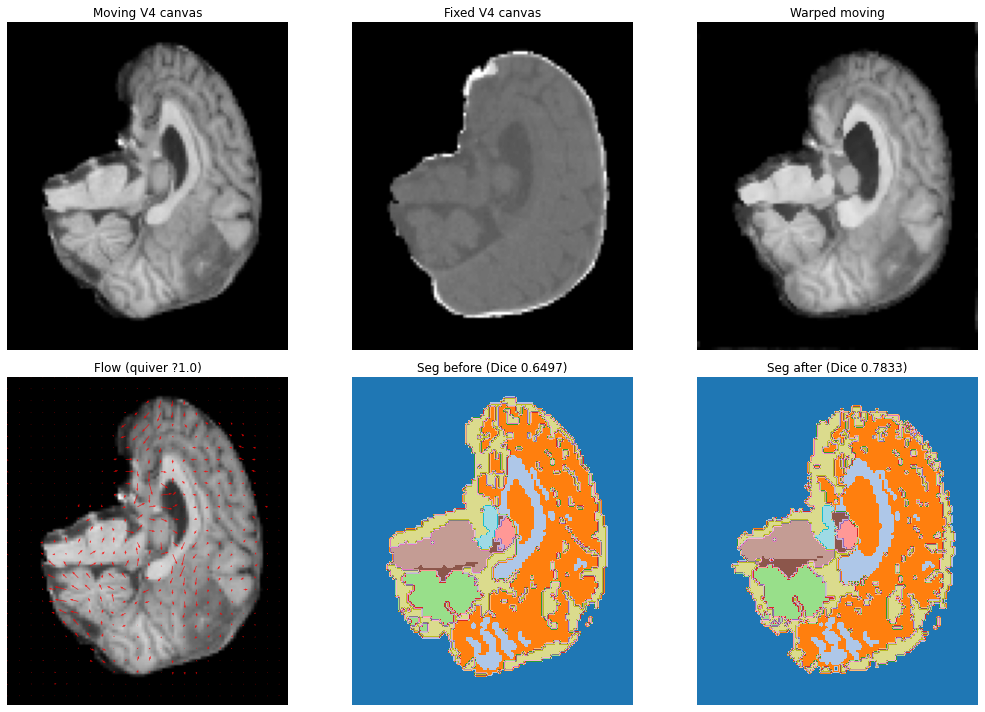

In [9]:
z_center = moving_c.shape[0] // 2
moving_stack = letterbox_stack_v4(extract_v4_stack(moving_c, 'axial', z_center), 'axial')
fixed_stack = letterbox_stack_v4(extract_v4_stack(fixed_c, 'axial', z_center), 'axial')
flow, inf_time = run_dpu_inference(moving_stack, fixed_stack)
center_index = WINDOW_RADIUS
moving_center, fixed_center = moving_stack[center_index], fixed_stack[center_index]
warped = apply_flow_2d(moving_center, flow)

if has_seg:
    moving_seg_c = resample_volume_v4(moving_seg_raw, is_segmentation=True)
    fixed_seg_c = resample_volume_v4(fixed_seg_raw, is_segmentation=True)
    moving_seg_canvas = letterbox_plane_v4(moving_seg_c[z_center], 'axial', is_segmentation=True)
    fixed_seg_canvas = letterbox_plane_v4(fixed_seg_c[z_center], 'axial', is_segmentation=True)
    warped_seg = apply_flow_2d(moving_seg_canvas, flow, interpolation=cv2.INTER_NEAREST).astype(np.int16)
    dice_before = compute_dice_per_label(moving_seg_canvas, fixed_seg_canvas).mean()
    dice_after = compute_dice_per_label(warped_seg, fixed_seg_canvas).mean()

print(f'V4 axial slice input: {moving_stack.shape}; flow: {flow.shape}; inference: {inf_time * 1000:.2f} ms')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, image, title in [(axes[0,0], moving_center, 'Moving V4 canvas'), (axes[0,1], fixed_center, 'Fixed V4 canvas'), (axes[0,2], warped, 'Warped moving')]:
    ax.imshow(image, cmap='gray'); ax.set_title(title); ax.axis('off')
q_gain, _ = plot_quiver(axes[1,0], flow, moving_center, auto_gain=QUIVER_AUTO_GAIN, target_p95=QUIVER_TARGET_P95, max_gain=QUIVER_MAX_GAIN, display_flip_y=QUIVER_DISPLAY_FLIP_Y)
axes[1,0].set_title(f'Flow (quiver ?{q_gain:.1f})'); axes[1,0].axis('off')
if has_seg:
    axes[1,1].imshow(moving_seg_canvas, cmap='tab20'); axes[1,1].set_title(f'Seg before (Dice {dice_before:.4f})')
    axes[1,2].imshow(warped_seg, cmap='tab20'); axes[1,2].set_title(f'Seg after (Dice {dice_after:.4f})')
for ax in axes[1,1:]: ax.axis('off')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/single_slice_v4.png', dpi=150); plt.show()


In [10]:
import gc

SUBJECTS = ['1BA111', '1BA116', '1BA125', '1BA131', '1BA141', '1BA143', '1BA151', '1BA158', '1BA159', '1BA164', '1BA172', '1BA175', '1BA184', '1BA185', '1BA189', '1BA201', '1BA206', '1BA220']
PAIRS = [(2, 17), (1, 12), (6, 0), (16, 4), (14, 8), (5, 9), (13, 11), (7, 10), (15, 3)]
WEIGHTS_PATH = resolve_file('./2p5d_dense_pt_v4_canonical_best.pth', ['../trained_weights/2p5d_dense_pt_v4_canonical_best.pth', '/home/xilinx/jupyter_notebooks/fpga_run_new/2p5d_dense_pt_v4_canonical_best.pth'])

print('Running power rail calibration (3s idle period)...')
rails = pynq.get_rails(); idle_dpu_samples = []; idle_cpu_samples = []
for _ in range(30):
    if 'INT' in rails and rails['INT'].power: idle_dpu_samples.append(rails['INT'].power.value)
    if 'PSINTFP' in rails and rails['PSINTFP'].power: idle_cpu_samples.append(rails['PSINTFP'].power.value)
    time.sleep(0.1)
IDLE_DPU_W = float(np.mean(idle_dpu_samples)) if idle_dpu_samples else 0.0
IDLE_CPU_W = float(np.mean(idle_cpu_samples)) if idle_cpu_samples else 0.0

methods = ['v4_axial', 'v4_mean_fused', 'v4_smoothed_0p75']
all_device_summaries = {}
for dev in ['fpga', 'cpu']:
    print(f'\nStarting V4 benchmark: {dev.upper()}')
    pair_summaries = []
    for pair_index, (moving_index, fixed_index) in enumerate(PAIRS):
        moving_id, fixed_id = SUBJECTS[moving_index], SUBJECTS[fixed_index]
        print(f'Pair {pair_index + 1}/9: {moving_id} MR -> {fixed_id} CT')
        try:
            moving_raw = normalize_volume_contract(np.load(resolve_file(f'./{moving_id}_mr.npy', [f'./data/test_data/{moving_id}_mr.npy'])).astype(np.float32))
            fixed_raw = normalize_volume_contract(np.load(resolve_file(f'./{fixed_id}_ct.npy', [f'./data/test_data/{fixed_id}_ct.npy'])).astype(np.float32))
            moving_seg = np.load(resolve_file(f'./{moving_id}_mr_seg.npy', [f'./data/test_data/{moving_id}_mr_seg.npy'])).astype(np.int16)
            fixed_seg = np.load(resolve_file(f'./{fixed_id}_ct_seg.npy', [f'./data/test_data/{fixed_id}_ct_seg.npy'])).astype(np.int16)
        except Exception as exc:
            print(f'  Skipping pair: {exc}'); continue
        moving_c = normalize_volume_contract(resample_volume_v4(moving_raw))
        fixed_c = normalize_volume_contract(resample_volume_v4(fixed_raw))

        with PowerMonitor(dev, idle_dpu_w=IDLE_DPU_W, idle_cpu_w=IDLE_CPU_W) as axial_infer_meter:
            axial_flow, run_a = infer_v4_orientation(moving_c, fixed_c, 'axial', dev, WEIGHTS_PATH)
            field_a = lift_axial_v4(axial_flow)
        axial_infer_power = axial_infer_meter.result()
        with PowerMonitor(dev, idle_dpu_w=IDLE_DPU_W, idle_cpu_w=IDLE_CPU_W) as coronal_infer_meter:
            coronal_flow, run_c = infer_v4_orientation(moving_c, fixed_c, 'coronal', dev, WEIGHTS_PATH)
            field_c = lift_coronal_v4(coronal_flow)
        coronal_infer_power = coronal_infer_meter.result()
        with PowerMonitor(dev, idle_dpu_w=IDLE_DPU_W, idle_cpu_w=IDLE_CPU_W) as sagittal_infer_meter:
            sagittal_flow, run_s = infer_v4_orientation(moving_c, fixed_c, 'sagittal', dev, WEIGHTS_PATH)
            field_s = lift_sagittal_v4(sagittal_flow)
        sagittal_infer_power = sagittal_infer_meter.result()
        variants = {'v4_axial': field_a, 'v4_mean_fused': fuse_fields(field_a, field_c, field_s)}
        inference_power_parts = {
            'v4_axial': [axial_infer_power],
            'v4_mean_fused': [axial_infer_power, coronal_infer_power, sagittal_infer_power],
            'v4_smoothed_0p75': [axial_infer_power, coronal_infer_power, sagittal_infer_power],
        }
        variants['v4_smoothed_0p75'] = smooth_field_3d(variants['v4_mean_fused'], sigma=0.75)
        pair_summary = {'pair_index': pair_index, 'moving_idx': moving_index, 'fixed_idx': fixed_index}
        for method, canonical_flow in variants.items():
            with PowerMonitor(dev, idle_dpu_w=IDLE_DPU_W, idle_cpu_w=IDLE_CPU_W) as post_meter:
                start = time.perf_counter()
                raw_flow = canonical_field_to_raw(canonical_flow, moving_raw.shape)
                warped = warp_volume_3d_numpy(moving_raw, raw_flow, mode='linear')
                warped_seg = warp_volume_3d_numpy(moving_seg, raw_flow, mode='nearest').astype(np.int16)
                summary = summarize_registration(moving_raw, fixed_raw, moving_seg, fixed_seg, raw_flow, warped, warped_seg)
                post_ms = (time.perf_counter() - start) * 1000.0
            inference_ms = float(np.sum(run_a) * 1000.0) if method == 'v4_axial' else float((np.sum(run_a) + np.sum(run_c) + np.sum(run_s)) * 1000.0)
            summary.update(model_inference_ms=inference_ms, postprocess_ms=float(post_ms), total_runtime_ms=float(inference_ms + post_ms))
            attach_power(summary, combine_power_measurements(inference_power_parts[method] + [post_meter.result()]))
            pair_summary[method] = summary
        pair_summaries.append(pair_summary)
        print('  ' + ' | '.join(f"{method}: Dice {pair_summary[method]['dice_after']:.4f}, TRE {pair_summary[method]['tre_mm']:.3f} mm" for method in methods))
        del field_a, field_c, field_s, variants; gc.collect()

    aggregated = {}
    for method in methods:
        values = [item[method] for item in pair_summaries]
        aggregate_keys = ['dice_before', 'dice_after', 'mi_before', 'mi_after', 'ssim_deformed_fixed', 'ssim_deformed_moving', 'tre_before_mm', 'tre_mm', 'tre_median_mm', 'tre_label_count', 'model_inference_ms', 'postprocess_ms', 'total_runtime_ms', 'energy_j', 'dynamic_energy_j', 'cpu_energy_j', 'cpu_dynamic_energy_j', 'gpu_energy_j', 'gpu_dynamic_energy_j', 'power_mean_w', 'process_rss_delta_mb']
        aggregated[method] = {key: float(np.mean([item[key] for item in values if item.get(key) is not None])) for key in aggregate_keys}
        aggregated[method]['gpu_power_peak_w'] = float(np.max([item['gpu_power_peak_w'] for item in values if item.get('gpu_power_peak_w') is not None])) if dev == 'fpga' else 0.0
        aggregated[method]['process_rss_peak_mb'] = float(np.max([item['process_rss_peak_mb'] for item in values if item.get('process_rss_peak_mb') is not None]))
    all_device_summaries[dev] = {'methods': aggregated, 'pairs': pair_summaries}

print('\nV4 CPU vs FPGA summary')
for method in methods:
    for dev in ['cpu', 'fpga']:
        metric = all_device_summaries[dev]['methods'][method]
        print(f"{method:22s} {dev:4s} Dice={metric['dice_after']:.4f}, TRE={metric['tre_mm']:.3f} mm, model={metric['model_inference_ms']:.1f} ms")

output_payload = {'pipeline_version': PIPELINE_VERSION, 'canonical_volume_shape': list(CANONICAL_VOLUME_SHAPE), 'input_shape_nhwc': [1, INPUT_HEIGHT, INPUT_WIDTH, INPUT_CHANNELS], 'tre_definition': 'segmentation-derived anatomical-label-centroid TRE in mm', 'calibration': {'idle_dpu_w': IDLE_DPU_W, 'idle_cpu_w': IDLE_CPU_W}, 'pair_count': len(PAIRS), 'fpga': all_device_summaries['fpga'], 'cpu': all_device_summaries['cpu']}
with open('benchmark_results_comparison_v4.json', 'w') as handle: json.dump(output_payload, handle, indent=2)
print('Saved benchmark_results_comparison_v4.json')


Running power rail calibration (3s idle period)...

Starting V4 benchmark: FPGA
Pair 1/9: 1BA125 MR -> 1BA220 CT
  v4_axial: Dice 0.7154, TRE 2.206 mm | v4_mean_fused: Dice 0.7805, TRE 1.603 mm | v4_smoothed_0p75: Dice 0.7784, TRE 1.650 mm
Pair 2/9: 1BA116 MR -> 1BA184 CT
  v4_axial: Dice 0.6751, TRE 2.751 mm | v4_mean_fused: Dice 0.7612, TRE 1.996 mm | v4_smoothed_0p75: Dice 0.7560, TRE 1.997 mm
Pair 3/9: 1BA151 MR -> 1BA111 CT
  v4_axial: Dice 0.7750, TRE 1.865 mm | v4_mean_fused: Dice 0.7881, TRE 1.750 mm | v4_smoothed_0p75: Dice 0.7875, TRE 1.724 mm
Pair 4/9: 1BA206 MR -> 1BA141 CT
  v4_axial: Dice 0.7414, TRE 2.242 mm | v4_mean_fused: Dice 0.7588, TRE 2.494 mm | v4_smoothed_0p75: Dice 0.7516, TRE 2.496 mm
Pair 5/9: 1BA189 MR -> 1BA159 CT
  v4_axial: Dice 0.7144, TRE 2.724 mm | v4_mean_fused: Dice 0.7689, TRE 2.510 mm | v4_smoothed_0p75: Dice 0.7620, TRE 2.521 mm
Pair 6/9: 1BA143 MR -> 1BA164 CT
  v4_axial: Dice 0.7048, TRE 2.877 mm | v4_mean_fused: Dice 0.7792, TRE 1.891 mm | v4_s

In [11]:
del dpu_runner
del graph
print("Done")

Done


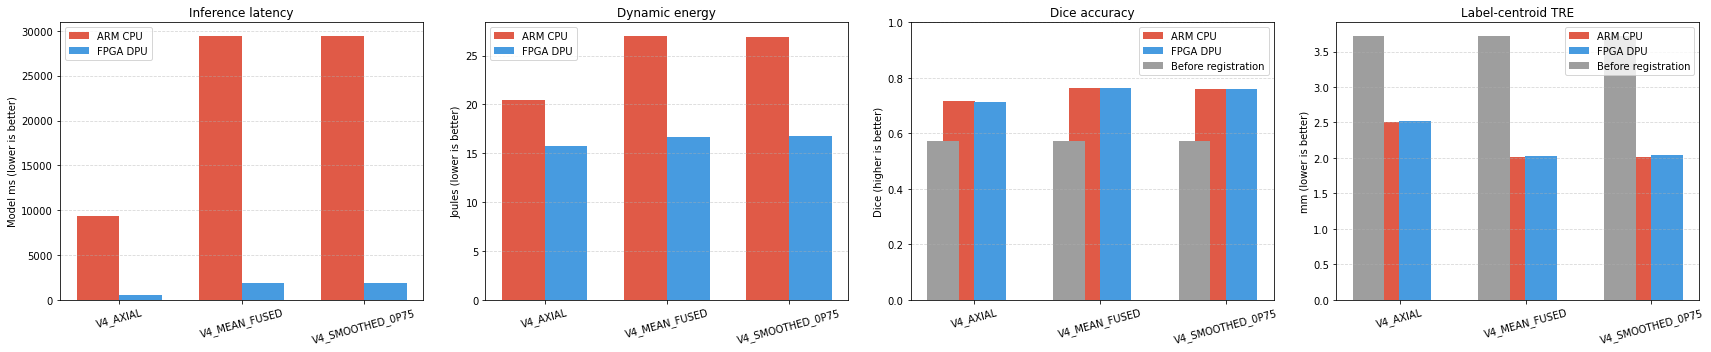

v4_axial: FPGA model speedup 16.17x; FPGA TRE 2.520 mm; CPU TRE 2.500 mm
v4_mean_fused: FPGA model speedup 16.17x; FPGA TRE 2.025 mm; CPU TRE 2.008 mm
v4_smoothed_0p75: FPGA model speedup 16.17x; FPGA TRE 2.036 mm; CPU TRE 2.014 mm


In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('benchmark_results_comparison_v4.json', 'r') as handle:
    results = json.load(handle)
methods = ['v4_axial', 'v4_mean_fused', 'v4_smoothed_0p75']
devices = ['cpu', 'fpga']
latencies = {dev: [results[dev]['methods'][method]['model_inference_ms'] for method in methods] for dev in devices}
energy = {dev: [results[dev]['methods'][method]['dynamic_energy_j'] for method in methods] for dev in devices}
dice_before = [results['fpga']['methods'][method]['dice_before'] for method in methods]
dice = {dev: [results[dev]['methods'][method]['dice_after'] for method in methods] for dev in devices}
tre_before = [results['fpga']['methods'][method]['tre_before_mm'] for method in methods]
tre = {dev: [results[dev]['methods'][method]['tre_mm'] for method in methods] for dev in devices}

x = np.arange(len(methods)); width = 0.25
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for dev, offset, color, label in [('cpu', -0.175, '#E05A47', 'ARM CPU'), ('fpga', 0.175, '#479BE0', 'FPGA DPU')]:
    axes[0].bar(x + offset, latencies[dev], 0.35, label=label, color=color)
    axes[1].bar(x + offset, energy[dev], 0.35, label=label, color=color)
    axes[2].bar(x + (offset + 0.0) * 0.7, dice[dev], width, label=label, color=color)
    axes[3].bar(x + (offset + 0.0) * 0.7, tre[dev], width, label=label, color=color)
axes[2].bar(x - width, dice_before, width, label='Before registration', color='#9E9E9E')
axes[3].bar(x - width, tre_before, width, label='Before registration', color='#9E9E9E')
for axis, title, ylabel in zip(axes, ['Inference latency', 'Dynamic energy', 'Dice accuracy', 'Label-centroid TRE'], ['Model ms (lower is better)', 'Joules (lower is better)', 'Dice (higher is better)', 'mm (lower is better)']):
    axis.set_title(title); axis.set_ylabel(ylabel); axis.set_xticks(x); axis.set_xticklabels([method.upper() for method in methods], rotation=15); axis.grid(axis='y', linestyle='--', alpha=0.5); axis.legend()
axes[2].set_ylim(0, 1.0)
plt.tight_layout(); plt.savefig('benchmark_charts_v4.png', dpi=150); plt.show()

for method in methods:
    cpu, fpga = results['cpu']['methods'][method], results['fpga']['methods'][method]
    print(f"{method}: FPGA model speedup {cpu['model_inference_ms'] / fpga['model_inference_ms']:.2f}x; FPGA TRE {fpga['tre_mm']:.3f} mm; CPU TRE {cpu['tre_mm']:.3f} mm")
